<img src="https://raw.githubusercontent.com/carubbi/MQ/b58af070c45fb17b77640c06c0016859ad366b4d/notebooks/assets/imgs/UNIFOR_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos em Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>
**Discentes:**<br>
Arthur Ramos Souza - 2513831<br>
Samylla Miguel Barbosa - 2517429

# AP 1 — AMES HOUSING
Como se distribuem e variam os preços de venda de imóveis residenciais?

# 1. Dados e variáveis

## 1.1 Bibliotecas


In [1242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1.2 Fonte dos dados


Arquivo `AmesHousing.txt`, disponibilizado pelo professor, com dados de Dean De Cock. A leitura usa diretamente a URL indicada, separador '\t' e codificação UTF-8.


In [1243]:
url = "https://raw.githubusercontent.com/carubbi/MQ/main/data/raw/AmesHousing.txt"
dataframe = pd.read_csv(url, sep='\t', encoding="utf-8")

## 1.3 Dimensões


In [1244]:
print("Linhas:", dataframe.shape[0])
print("Colunas:", dataframe.shape[1])


Linhas: 2930
Colunas: 82


## 1.4 Unidade de análise


Cada linha representa um registro de venda de imóvel residencial em Ames, Iowa, Estados Unidos, entre 2006 e 2010. São 2.930 registros e 82 colunas na base de referência; os preços estão em dólares nominais da época da venda.


## 1.5 Inspeção inicial


In [1245]:
dataframe.head()


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [1246]:
print(dataframe.columns.tolist())


['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck 

## 1.6 Variáveis selecionadas


B representa o tipo de imóvel (`Bldg Type`). É uma variável qualitativa nominal: os tipos não têm ordem de qualidade. Os nomes originais das colunas são preservados.

In [1247]:
cols_sel = ["SalePrice", "Gr Liv Area", "Yr Sold", "Bldg Type", "Fireplaces",
            "Mas Vnr Area", "Year Remod/Add", "Year Built"]
df_original = dataframe.copy()
df = dataframe[cols_sel].copy()

nomes = ["Preço de venda", "Área habitável acima do solo", "Ano da venda",
         "Tipo de imóvel", "Quantidade de lareiras",
         "Área de revestimento de alvenaria", "Ano de reforma/ampliação", "Ano de construção"]
unidades = ["US$", "ft²", "ano", "categoria nominal", "lareiras", "ft²", "ano", "ano"]

variaveis = pd.DataFrame({"Nome legível": nomes, "Nome original": cols_sel,
                         "Nome utilizado": cols_sel, "Unidade": unidades})
variaveis

,Nome legível,Nome original,Nome utilizado,Unidade
0,Preço de venda,SalePrice,SalePrice,US$
1,Área habitável acima do solo,Gr Liv Area,Gr Liv Area,ft²
2,Ano da venda,Yr Sold,Yr Sold,ano
3,Tipo de imóvel,Bldg Type,Bldg Type,categoria nominal
4,Quantidade de lareiras,Fireplaces,Fireplaces,lareiras
5,Área de revestimento de alvenaria,Mas Vnr Area,Mas Vnr Area,ft²
6,Ano de reforma/ampliação,Year Remod/Add,Year Remod/Add,ano
7,Ano de construção,Year Built,Year Built,ano


**Tabela 1 - Variáveis selecionadas.** Os nomes originais foram mantidos. B indica o tipo de imóvel, e não um nível de qualidade.

# 2. Qualidade e preparação


## 2.1 Tipos e ausências


In [1248]:
qualidade = pd.DataFrame({"Tipo original": df.dtypes,
                          "Válidos": df.count(),
                          "Ausentes": df.isna().sum(),
                          "Ausentes (%)": df.isna().sum() / len(df) * 100})
qualidade.round(2)


,Tipo original,Válidos,Ausentes,Ausentes (%)
SalePrice,int64,2930,0,0.00
Gr Liv Area,int64,2930,0,0.00
Yr Sold,int64,2930,0,0.00
Bldg Type,object,2930,0,0.00
Fireplaces,int64,2930,0,0.00
Mas Vnr Area,float64,2907,23,0.78
Year Remod/Add,int64,2930,0,0.00
Year Built,int64,2930,0,0.00


**Tabela 2 - Tipos e valores ausentes.** As colunas numéricas já foram lidas como números. `Bldg Type` contém categorias nominais. Somente `Mas Vnr Area` tem ausências nas oito colunas selecionadas: 23 registros, que serão preservados.

## 2.2 Duplicidades e consistência


In [1249]:
verificacoes = pd.DataFrame({
    "Verificação": ["Linhas completas duplicadas", "Identificadores Order repetidos",
                    "Preço não positivo", "Área não positiva", "Lareiras negativas",
                    "Revestimento com área negativa", "Reforma anterior à construção",
                    "Construção posterior à venda", "Reforma posterior à venda"],
    "Quantidade": [df_original.duplicated().sum(), df_original["Order"].duplicated().sum(),
                   (df["SalePrice"] <= 0).sum(), (df["Gr Liv Area"] <= 0).sum(),
                   (df["Fireplaces"] < 0).sum(), (df["Mas Vnr Area"] < 0).sum(),
                   (df["Year Remod/Add"] < df["Year Built"]).sum(),
                   (df["Year Built"] > df["Yr Sold"]).sum(),
                   (df["Year Remod/Add"] > df["Yr Sold"]).sum()]
})
verificacoes


,Verificação,Quantidade
0,Linhas completas duplicadas,0
1,Identificadores Order repetidos,0
2,Preço não positivo,0
3,Área não positiva,0
4,Lareiras negativas,0
5,Revestimento com área negativa,0
6,Reforma anterior à construção,1
7,Construção posterior à venda,1
8,Reforma posterior à venda,3


**Tabela 3 - Verificações de consistência.** Não há linhas completas duplicadas nem identificadores `Order` repetidos. As verificações de datas podem contar o mesmo registro.

In [1250]:
datas_inconsistentes = ((df["Year Remod/Add"] < df["Year Built"]) |
                       (df["Year Built"] > df["Yr Sold"]) |
                       (df["Year Remod/Add"] > df["Yr Sold"]))
df_original.loc[datas_inconsistentes, ["Order", "Year Built", "Year Remod/Add", "Yr Sold"]]


,Order,Year Built,Year Remod/Add,Yr Sold
850,851,2002,2001,2009
1702,1703,2007,2008,2007
2180,2181,2008,2009,2007
2181,2182,2007,2008,2007


**Tabela 4 - Registros com datas inconsistentes.** Quatro imóveis apresentam alguma incompatibilidade entre os anos. Os valores serão preservados, pois não há confirmação das datas corretas.

## 2.3 Significado e tratamentos


Segundo a [documentação de Ames Housing](https://jse.amstat.org/v19n3/decock/DataDocumentation.txt), `Fireplaces` conta lareiras e zero significa nenhuma; `Mas Vnr Area` mede revestimento em ft² e ausência de informação não significa área zero. `Year Remod/Add` repete `Year Built` quando não há reforma/ampliação registrada.


Os 23 valores ausentes de `Mas Vnr Area` permanecem ausentes. As datas inconsistentes são preservadas por falta de evidência para corrigi-las e precisam de revisão antes de cálculos de idade/reforma na AP2. Nenhuma linha é removida, e `df_original` conserva a cópia lógica completa.


In [1251]:
preco = df["SalePrice"]
area = df["Gr Liv Area"]
predio = df["Bldg Type"]


# 3. Análise univariada


## 3.1 Preparação das medidas


As medidas individuais têm cálculos manuais e com pandas em células separadas. Todas as tabelas usam apenas pandas; `dropna()` desconsidera ausências somente no cálculo, e a variância e o desvio-padrão usam o denominador n − 1.


In [1252]:
# Define a preparação comum que remove ausências e verifica o tamanho mínimo.
def _validos(valores: pd.Series, minimo: int = 1) -> pd.Series:
    """Remove ausências de uma série sem convertê-la."""
    if not isinstance(valores, pd.Series):
        raise TypeError(
            "valores deve ser pandas.Series numérica ou booleana; "
            "converta listas antes com pd.Series(valores)."
        )
    serie = valores.dropna()
    if len(serie) < minimo:
        raise ValueError(
            f"São necessárias pelo menos {minimo} observações válidas."
        )
    return serie


## 3.2 Quantidade, mínimo e máximo


A quantidade corresponde ao número de valores preenchidos. O mínimo é o menor valor observado, e o máximo é o maior.


**Manual**


In [1253]:
n_preco = len(_validos(preco))
n_area = len(_validos(area))
min_preco, max_preco = min(_validos(preco)), max(_validos(preco))
min_area, max_area = min(_validos(area)), max(_validos(area))
print("Preço — n, mínimo e máximo:", n_preco, min_preco, max_preco)
print("Área — n, mínimo e máximo:", n_area, min_area, max_area)


Preço — n, mínimo e máximo: 2930 12789 755000
Área — n, mínimo e máximo: 2930 334 5642


**Pandas**


In [1254]:
n_preco_pd, n_area_pd = preco.count(), area.count()
min_preco_pd, max_preco_pd = preco.min(), preco.max()
min_area_pd, max_area_pd = area.min(), area.max()
print("Preço — n, mínimo e máximo:", n_preco_pd, min_preco_pd, max_preco_pd)
print("Área — n, mínimo e máximo:", n_area_pd, min_area_pd, max_area_pd)


Preço — n, mínimo e máximo: 2930 12789 755000
Área — n, mínimo e máximo: 2930 334 5642


## 3.3 Média


$$
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i.
$$

A média é a soma dos valores dividida pela quantidade de observações; $n$ é a quantidade válida e $x_i$ é cada valor.


**Manual**


In [1255]:
def media(valores):
  serie = _validos(valores)
  return sum(serie)/len(serie)

media_preco = media(preco)
media_area = media(area)
print("Preço:", round(media_preco, 2), "US$")
print("Área:", round(media_area, 2), "ft²")


Preço: 180796.06 US$
Área: 1499.69 ft²


**Pandas**


In [1256]:
def media_pd(valores):
  serie = _validos(valores)
  return serie.mean()

media_preco_pd = media_pd(preco)
media_area_pd = media_pd(area)
print("Preço:", round(media_preco_pd, 2), "US$")
print("Área:", round(media_area_pd, 2), "ft²")


Preço: 180796.06 US$
Área: 1499.69 ft²


## 3.4 Mediana


$$
\widetilde{x}=
\begin{cases}
x_{\left(\frac{n+1}{2}\right)}, & n\ \text{ímpar},\\[6pt]
\dfrac{x_{\left(\frac{n}{2}\right)}+
x_{\left(\frac{n}{2}+1\right)}}{2}, & n\ \text{par}.
\end{cases}
$$

Após ordenar os valores, a mediana é o valor central ou a média dos dois centrais. $x_{(r)}$ representa o valor na posição $r$ da lista ordenada.


**Manual**


In [1257]:
# Implementa a mediana diretamente a partir dos dados ordenados.
def mediana(valores: pd.Series) -> float:
    """Calcula a mediana depois de ordenar uma cópia dos valores."""
    ordenados = sorted(_validos(valores))
    n = len(ordenados)
    meio = n // 2
    if n % 2 == 1:
        return ordenados[meio]
    return (ordenados[meio - 1] + ordenados[meio]) / 2

mediana_preco = mediana(preco)
mediana_area = mediana(area)
print("Preço:", mediana_preco, "US$")
print("Área:", mediana_area, "ft²")


Preço: 160000.0 US$
Área: 1442.0 ft²


**Pandas**


In [1258]:
def mediana_pd(valores):
    serie = _validos(valores)
    return serie.median()

mediana_preco_pd = mediana_pd(preco)
mediana_area_pd = mediana_pd(area)
print("Preço:", mediana_preco_pd, "US$")
print("Área:", mediana_area_pd, "ft²")


Preço: 160000.0 US$
Área: 1442.0 ft²


## 3.5 Moda


$$
\nu(v)=\sum_{i=1}^{n}\mathbb{1}(x_i=v).
$$

$$
\operatorname{Mo}(x)=
\left\{v:\nu(v)=\max_{u}\nu(u)\right\}.
$$

$\nu(v)$ conta quantas vezes o valor $v$ aparece; $\mathbb{1}(x_i=v)$ vale 1 quando os valores são iguais e 0 nos demais casos. A moda reúne todos os valores com a maior frequência.


**Manual**


In [1259]:
def modas(valores):
    serie = _validos(valores)
    freq = serie.value_counts()
    modais = freq[freq == freq.max()].index
    return sorted(modais)

moda_preco = modas(preco)
moda_area = modas(area)
print("Preço:", moda_preco, "US$")
print("Área:", moda_area, "ft²")


Preço: [135000] US$
Área: [864] ft²


**Pandas**


In [1260]:
def modas_pd(valores):
    serie = _validos(valores)
    return serie.mode().to_list()

moda_preco_pd = modas_pd(preco)
moda_area_pd = modas_pd(area)
print("Preço:", moda_preco_pd, "US$")
print("Área:", moda_area_pd, "ft²")


Preço: [135000] US$
Área: [864] ft²


## 3.6 Quartis


$$
I(h)=
\begin{cases}
x_{(1)}, & h\leq1,\\[3pt]
(1-d)x_{(i)}+d x_{(i+1)}, & 1<h<n,\\[3pt]
x_{(n)}, & h\geq n.
\end{cases}
$$

$$
p=\frac{j}{m}.
$$

$$
\begin{gathered}
H_p=1+(n-1)p,\qquad q_p=I(H_p).
\end{gathered}
$$

Para quartis, $m=4$ e $j=1,2,3$, correspondendo a 25%, 50% e 75% dos dados ordenados. Na interpolação, $i=\lfloor h\rfloor$ é a parte inteira da posição e $d=h-i$ é sua parte decimal.


**Manual**


In [1261]:
# Define a interpolação de uma posição teórica
def _interpolar_posicao(ordenados: list[float], h: float) -> float:
    """Interpola uma posição matemática h, indexada a partir de 1."""
    n = len(ordenados)
    if h <= 1:
        return ordenados[0]
    if h >= n:
        return ordenados[-1]

    i = int(h)
    d = h - i
    x_i = ordenados[i - 1]
    x_sup = ordenados[i]
    return x_i + d * (x_sup - x_i)


In [1262]:
# Calcula o quantil pela definição
def quantil(valores: pd.Series, p: float) -> float:
    """Calcula q_p por interpolação linear."""
    if not 0 <= p <= 1:
        raise ValueError("p deve pertencer ao intervalo [0, 1].")

    ordenados = sorted(_validos(valores))
    h = 1 + (len(ordenados) - 1) * p
    return _interpolar_posicao(ordenados, h)

q1_preco = quantil(preco, 0.25)
q2_preco = quantil(preco, 0.50)
q3_preco = quantil(preco, 0.75)
q1_area = quantil(area, 0.25)
q2_area = quantil(area, 0.50)
q3_area = quantil(area, 0.75)
print("Preço — Q1, Q2, Q3:", q1_preco, q2_preco, q3_preco)
print("Área — Q1, Q2, Q3:", q1_area, q2_area, q3_area)


Preço — Q1, Q2, Q3: 129500.0 160000.0 213500.0
Área — Q1, Q2, Q3: 1126.0 1442.0 1742.75


**Pandas**


In [1263]:
def quantil_pd(valores, p):
    if not 0 <= p <= 1:
      raise ValueError('p deve estar entre 0 e 1')
    serie = _validos(valores)
    return serie.quantile(p, interpolation='linear')

q1_preco_pd = quantil_pd(preco, 0.25)
q2_preco_pd = quantil_pd(preco, 0.50)
q3_preco_pd = quantil_pd(preco, 0.75)
q1_area_pd = quantil_pd(area, 0.25)
q2_area_pd = quantil_pd(area, 0.50)
q3_area_pd = quantil_pd(area, 0.75)
print("Preço — Q1, Q2, Q3:", q1_preco_pd, q2_preco_pd, q3_preco_pd)
print("Área — Q1, Q2, Q3:", q1_area_pd, q2_area_pd, q3_area_pd)


Preço — Q1, Q2, Q3: 129500.0 160000.0 213500.0
Área — Q1, Q2, Q3: 1126.0 1442.0 1742.75


## 3.7 Amplitude


$$
R=x_{(n)}-x_{(1)}.
$$

A amplitude é a diferença entre o maior valor, $x_{(n)}$, e o menor, $x_{(1)}$.


**Manual**


In [1264]:
def amplitude(valores):
    serie = _validos(valores)
    return max(serie) - min(serie)

amplitude_preco = amplitude(preco)
amplitude_area = amplitude(area)
print("Preço:", amplitude_preco, "US$")
print("Área:", amplitude_area, "ft²")


Preço: 742211 US$
Área: 5308 ft²


**Pandas**


In [1265]:
def amplitude_pd(valores):
    serie = _validos(valores)
    return serie.max() - serie.min()

amplitude_preco_pd = amplitude_pd(preco)
amplitude_area_pd = amplitude_pd(area)
print("Preço:", amplitude_preco_pd, "US$")
print("Área:", amplitude_area_pd, "ft²")


Preço: 742211 US$
Área: 5308 ft²


## 3.8 Variância amostral


$$
s^2=\frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2.
$$

A variância amostral soma os desvios ao quadrado em relação à média e divide por $n-1$.


**Manual**


In [1266]:
# Implementa a variância amostral com denominador n menos 1.
def variancia(valores: pd.Series) -> float:
    """Calcula a variância amostral com denominador n - 1."""
    observados = _validos(valores, minimo=2)
    media_valor = media(observados)
    soma_quadrados = 0.0
    for valor in observados:
        soma_quadrados += (valor - media_valor) ** 2
    return soma_quadrados / (len(observados) - 1)

variancia_preco = variancia(preco)
variancia_area = variancia(area)
print("Preço:", round(variancia_preco, 2), "US$²")
print("Área:", round(variancia_area, 2), "ft⁴")


Preço: 6381883615.69 US$²
Área: 255539.24 ft⁴


**Pandas**


In [1267]:
# Implementa a variância amostral com pandas e ddof igual a 1.
def variancia_pd(valores: pd.Series) -> float:
    """Calcula a variância amostral com pandas e ddof=1."""
    serie = _validos(valores, minimo=2)
    return float(serie.var(ddof=1))

variancia_preco_pd = variancia_pd(preco)
variancia_area_pd = variancia_pd(area)
print("Preço:", round(variancia_preco_pd, 2), "US$²")
print("Área:", round(variancia_area_pd, 2), "ft⁴")


Preço: 6381883615.69 US$²
Área: 255539.24 ft⁴


## 3.9 Desvio-padrão amostral


$$
s=\sqrt{s^2}.
$$

O desvio-padrão é a raiz quadrada da variância e tem a mesma unidade dos dados.


**Manual**


In [1268]:
def desvio_padrao(valores):
    return variancia(valores) ** 0.5

desvio_preco = desvio_padrao(preco)
desvio_area = desvio_padrao(area)
print("Preço:", round(desvio_preco, 2), "US$")
print("Área:", round(desvio_area, 2), "ft²")


Preço: 79886.69 US$
Área: 505.51 ft²


**Pandas**


In [1269]:
def desvio_padrao_pd(valores):
    return _validos(valores, minimo=2).std(ddof=1)

desvio_preco_pd = desvio_padrao_pd(preco)
desvio_area_pd = desvio_padrao_pd(area)
print("Preço:", round(desvio_preco_pd, 2), "US$")
print("Área:", round(desvio_area_pd, 2), "ft²")


Preço: 79886.69 US$
Área: 505.51 ft²


## 3.10 Intervalo interquartil


$$IQR=Q_3-Q_1.$$ A medida representa a extensão dos 50% centrais dos dados.


**Manual**


In [1270]:
iqr_preco = q3_preco - q1_preco
iqr_area = q3_area - q1_area
print("Preço:", iqr_preco, "US$")
print("Área:", iqr_area, "ft²")


Preço: 84000.0 US$
Área: 616.75 ft²


**Pandas**


In [1271]:
iqr_preco_pd = preco.quantile(0.75) - preco.quantile(0.25)
iqr_area_pd = area.quantile(0.75) - area.quantile(0.25)
print("Preço:", iqr_preco_pd, "US$")
print("Área:", iqr_area_pd, "ft²")


Preço: 84000.0 US$
Área: 616.75 ft²


## 3.11 Resumo das medidas


In [1272]:
medidas = ["Quantidade", "Mínimo", "Máximo", "Média", "Mediana", "Moda", "Q1", "Q2", "Q3",
           "Amplitude", "Variância amostral", "Desvio-padrão amostral", "IQR"]

resumo = pd.DataFrame({
    "Medida": medidas,
    "Preço de venda": [preco.count(), preco.min(), preco.max(), preco.mean(), preco.median(),
                       preco.mode().to_list(), preco.quantile(0.25), preco.quantile(0.50),
                       preco.quantile(0.75), preco.max() - preco.min(), preco.var(ddof=1),
                       preco.std(ddof=1), preco.quantile(0.75) - preco.quantile(0.25)],
    "Área habitável": [area.count(), area.min(), area.max(), area.mean(), area.median(),
                      area.mode().to_list(), area.quantile(0.25), area.quantile(0.50),
                      area.quantile(0.75), area.max() - area.min(), area.var(ddof=1),
                      area.std(ddof=1), area.quantile(0.75) - area.quantile(0.25)]
}).set_index("Medida")
resumo


,Preço de venda,Área habitável
Medida,,
Quantidade,2930,2930
Mínimo,12789,334
Máximo,755000,5642
Média,180796.060068,1499.690444
Mediana,160000.0,1442.0
Moda,[135000],[864]
Q1,129500.0,1126.0
Q2,160000.0,1442.0
Q3,213500.0,1742.75


**Tabela 5 - Resumo de preço e área.** As médias superam as medianas nas duas variáveis. Preço está em US$ e área em ft²; as variâncias estão em US$² e ft⁴. Quantidade indica os valores preenchidos.

## 3.12 Histogramas


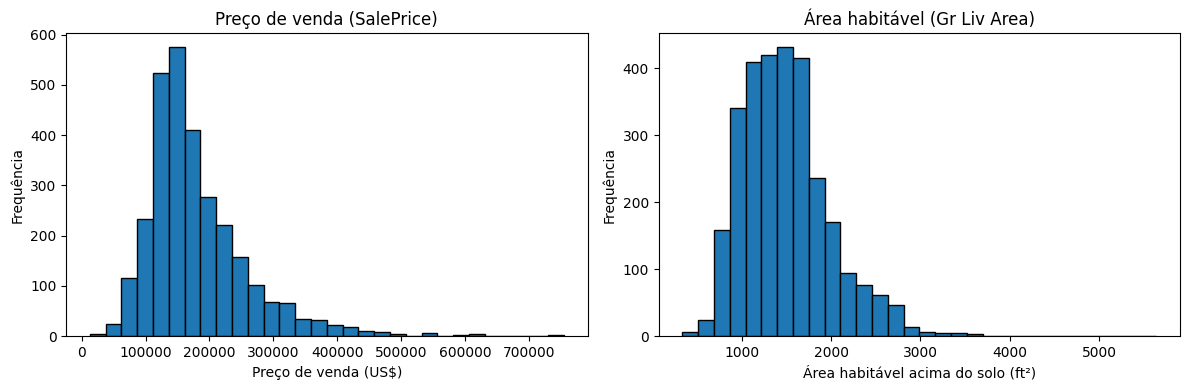

In [1273]:
# Usar o histograma da aula 06 em dois painéis.
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
for eixo, valores, titulo, unidade in zip(
    eixos, [preco, area],
    ["Preço de venda (SalePrice)", "Área habitável (Gr Liv Area)"],
    ["Preço de venda (US$)", "Área habitável acima do solo (ft²)"]
):
    plt.sca(eixo)
    plt.hist(valores, bins=30, edgecolor='black')
    plt.title(titulo)
    plt.xlabel(unidade)
    plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

**Figura 1 - Histogramas de preço e área.** As duas distribuições têm cauda à direita, com poucos valores muito altos. As médias (US$ 180.796,06 e 1.499,69 ft²) superam as medianas (US$ 160.000 e 1.442 ft²).

**Natureza observacional:** Os histogramas resumem vendas observadas, sem intervenção experimental.


**Período e local:** Os registros abrangem Ames, Iowa, de 2006 a 2010; os preços são nominais.


**Representatividade:** Imóveis vendidos nesse contexto não representam automaticamente todos os imóveis ou outras cidades.


**Decisões de preparação:** Foram usadas 30 classes por painel, sem transformação ou exclusão de preços e áreas; outra divisão muda a aparência das barras.


**Valor discrepante e erro:** As caudas mostram valores extremos, que precisam de contexto antes de serem considerados erros.


**Associação e causalidade:** Histogramas mostram cada variável isoladamente e não demonstram que maior área causa maior preço.


## 3.13 Frequências de B


B é o tipo de imóvel (`Bldg Type`). Ela descreve a organização da moradia, sem indicar qualidade ou número de andares.

| Código no arquivo | Significado |
|---|---|
| `1Fam` | Casa independente destinada a uma família. |
| `2fmCon` | Casa originalmente unifamiliar, convertida em duas unidades residenciais. |
| `Duplex` | Edificação com duas unidades residenciais; não significa necessariamente dois andares. |
| `TwnhsE` | Unidade na ponta de uma sequência de casas geminadas. |
| `Twnhs` | Unidade interna de uma sequência de casas geminadas. |

No código, usamos as grafias reais do arquivo: `2fmCon`, `Duplex` e `Twnhs`.

$$h_j=\frac{f_j}{n},\qquad p_j=100h_j.$$

A frequência relativa divide a contagem da categoria pelo total de valores preenchidos. O percentual multiplica essa proporção por 100.

In [1274]:
categorias = ["1Fam", "2fmCon", "Duplex", "TwnhsE", "Twnhs"]
rotulos = {
    "1Fam": "Casa independente (1Fam)",
    "2fmCon": "Casa convertida (2fmCon)",
    "Duplex": "Duas unidades (Duplex)",
    "TwnhsE": "Geminada na ponta (TwnhsE)",
    "Twnhs": "Geminada interna (Twnhs)"
}
freq = predio.value_counts().reindex(categorias, fill_value=0)
frequencia = freq.to_frame("Quantidade")
frequencia["Relativa"] = freq / predio.count()
frequencia["Percentual"] = frequencia["Relativa"] * 100
frequencia.index.name = "Tipo de imóvel (Bldg Type)"
frequencia.round(4)

,Quantidade,Relativa,Percentual
Tipo de imóvel (Bldg Type),,,
1Fam,2425,0.8276,82.7645
2fmCon,62,0.0212,2.1160
Duplex,109,0.0372,3.7201
TwnhsE,233,0.0795,7.9522
Twnhs,101,0.0345,3.4471


**Tabela 6 - Frequências de B.** As cinco categorias somam 2.930 registros. `1Fam` reúne cerca de 82,8% das vendas; `2fmCon`, cerca de 2,1%. As proporções usam os valores preenchidos.

## 3.14 Gráfico de barras de B


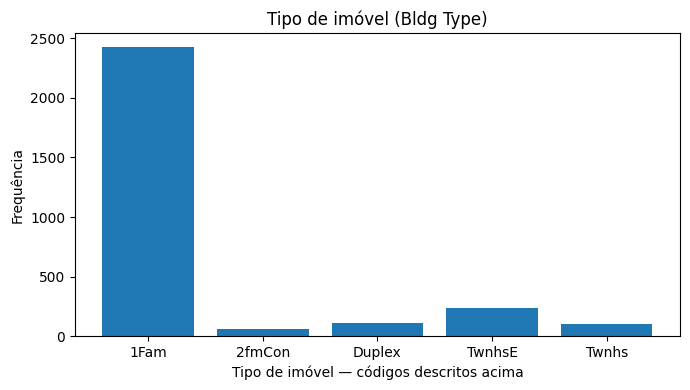

In [1275]:
# Construir o gráfico de barras como na aula 06.
plt.figure(figsize=(7, 4))
plt.bar(freq.index, freq.values)
plt.title('Tipo de imóvel (Bldg Type)')
plt.xlabel('Tipo de imóvel — códigos descritos acima')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

**Figura 2 - Frequências dos tipos de imóvel.** Casas independentes (`1Fam`) concentram 2.425 registros, cerca de 82,8% do total. Casas convertidas (`2fmCon`) são o menor grupo, com 62 registros. Não há ausências de B.

**Natureza observacional:** Os tipos de imóvel foram registrados nas vendas, sem intervenção experimental.

**Período e local:** As frequências se referem a Ames, Iowa, no período de 2006 a 2010.


**Representatividade:** As categorias têm tamanhos diferentes; suas frequências descrevem apenas as vendas desta base.

**Decisões de preparação:** Mantemos os cinco códigos originais. A ordem de apresentação não indica qualidade.

**Categoria pouco frequente e erro:** `2fmCon` é um tipo válido; ter menos registros não indica erro de preenchimento.

**Associação e causalidade:** A quantidade de imóveis de um tipo não demonstra sua influência sobre o preço.

# 4. Valores discrepantes

## 4.1 Cercas de Tukey

As cercas usam os quartis para sinalizar valores afastados da parte central dos dados.

$$LI=Q_1-1{,}5\,IQR,\qquad LS=Q_3+1{,}5\,IQR.$$

Um valor abaixo de LI ou acima de LS será investigado. Estar fora das cercas não prova que ele esteja errado.

In [1276]:
li_preco = q1_preco - 1.5 * iqr_preco
ls_preco = q3_preco + 1.5 * iqr_preco
li_area = q1_area - 1.5 * iqr_area
ls_area = q3_area + 1.5 * iqr_area

fora_preco = (preco < li_preco) | (preco > ls_preco)
fora_area = (area < li_area) | (area > ls_area)
cercas = pd.DataFrame({
    "Q1": [q1_preco, q1_area], "Q3": [q3_preco, q3_area],
    "IQR": [iqr_preco, iqr_area],
    "Limite inferior": [li_preco, li_area],
    "Limite superior": [ls_preco, ls_area],
    "Sinalizados": [fora_preco.sum(), fora_area.sum()]
}, index=["Preço de venda (SalePrice) — US$", "Área habitável (Gr Liv Area) — ft²"])
cercas

,Q1,Q3,IQR,Limite inferior,Limite superior,Sinalizados
Preço de venda (SalePrice) — US$,129500.0,213500.00,84000.00,3500.000,339500.000,137
Área habitável (Gr Liv Area) — ft²,1126.0,1742.75,616.75,200.875,2667.875,75


**Tabela 7 - Cercas de Tukey.** Há 137 preços acima de US$ 339.500 e 75 áreas acima de 2.667,875 ft². Nenhum valor fica abaixo da cerca inferior. Um imóvel pode ser sinalizado nas duas variáveis.

## 4.2 Boxplots de preço e área

A caixa vai de Q1 a Q3, e a linha interna marca a mediana. As hastes chegam aos valores observados dentro das cercas. Os pontos além delas são os casos sinalizados.

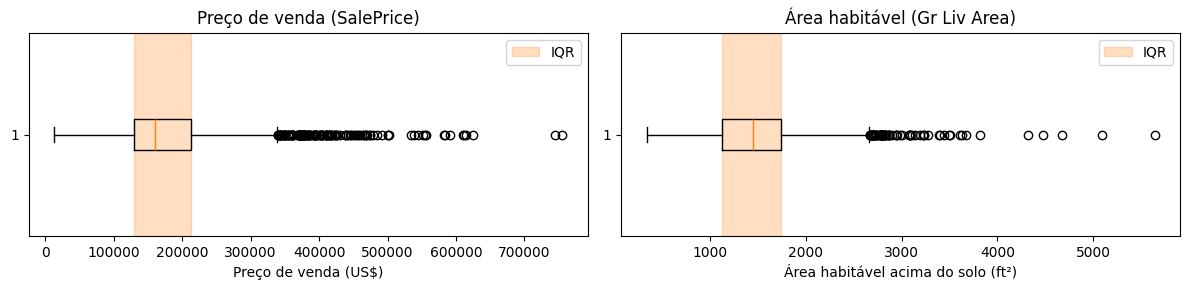

In [1277]:
# Repetir o boxplot horizontal da aula 07 em dois painéis.
fig, eixos = plt.subplots(1, 2, figsize=(12, 3))
for eixo, valores, q1, q3, titulo, unidade in zip(
    eixos, [preco, area], [q1_preco, q1_area], [q3_preco, q3_area],
    ["Preço de venda (SalePrice)", "Área habitável (Gr Liv Area)"],
    ["Preço de venda (US$)", "Área habitável acima do solo (ft²)"]
):
    eixo.boxplot(valores, vert=False)
    eixo.axvspan(q1, q3, color="tab:orange", alpha=0.25, label="IQR")
    eixo.set_xlabel(unidade)
    eixo.set_title(titulo)
    eixo.legend()
plt.tight_layout()
plt.show()

**Figura 3 - Boxplots de preço e área.** Os pontos sinalizados estão do lado dos valores altos. A faixa laranja destaca os 50% centrais de cada variável. As escalas são diferentes: US$ para preço e ft² para área.

## 4.3 Investigação dos valores sinalizados

Vamos separar todos os casos sinalizados e mostrar os cinco maiores preços e as cinco maiores áreas. O identificador `Order` permite localizar cada registro na base original.

In [1278]:
casos_sinalizados = df_original.loc[
    fora_preco | fora_area, ["Order", "SalePrice", "Gr Liv Area", "Bldg Type"]
].copy()
casos_sinalizados["Preço fora das cercas"] = fora_preco.loc[casos_sinalizados.index]
casos_sinalizados["Área fora das cercas"] = fora_area.loc[casos_sinalizados.index]
maiores_precos = casos_sinalizados.nlargest(5, "SalePrice")
maiores_areas = casos_sinalizados.nlargest(5, "Gr Liv Area")
inspecao = pd.concat([maiores_precos, maiores_areas]).drop_duplicates(subset="Order")
print("Imóveis sinalizados em pelo menos uma variável:", len(casos_sinalizados))
inspecao

Imóveis sinalizados em pelo menos uma variável: 173


,Order,SalePrice,Gr Liv Area,Bldg Type,Preço fora das cercas,Área fora das cercas
1767,1768,755000,4316,1Fam,True,True
1760,1761,745000,4476,1Fam,True,True
2445,2446,625000,3627,1Fam,True,True
1063,1064,615000,2470,1Fam,True,False
44,45,611657,2364,1Fam,True,False
1498,1499,160000,5642,1Fam,False,True
2180,2181,183850,5095,1Fam,False,True
2181,2182,184750,4676,1Fam,False,True


**Tabela 8 - Inspeção dos maiores valores.** O imóvel 1768 combina preço de US$ 755.000 e área de 4.316 ft². Já o 1499 tem a maior área (5.642 ft²), mas preço de US$ 160.000. Os registros 2181 e 2182 também têm áreas altas e aparecem nas inconsistências de datas.

**Decisão:** Todos os registros serão mantidos. Os casos combinam situações diferentes, e não temos evidência suficiente para corrigir ou excluir valores. Os resultados incluem esses extremos; seu tamanho, sozinho, não comprova erro.

# 5. Categorias finais de B

Antes de comparar preços, mantemos os cinco tipos separados: cada um tem significado próprio e o menor grupo possui 62 registros. Não há valores ausentes. Os grupos têm tamanhos diferentes, mas não há motivo para uni-los nesta descrição. Essa decisão usa os tipos e suas frequências, sem consultar os preços.

In [1279]:
ordem = [rotulos[categoria] for categoria in categorias]
df["tipo_imovel"] = df["Bldg Type"].map(rotulos)
df["tipo_imovel"] = pd.Categorical(
    df["tipo_imovel"], categories=ordem, ordered=False
)

A coluna `Bldg Type` conserva os códigos originais. A coluna `tipo_imovel` contém os rótulos em português. Não houve agrupamento; as categorias são nominais e serão mantidas para a AP3.

# 6. Análise bivariada

## 6.1 Preço por ano da venda

A tabela apresenta a quantidade de vendas e a mediana do preço em cada ano, em ordem cronológica.


In [1280]:
por_ano = df.groupby("Yr Sold")["SalePrice"]
anual = pd.DataFrame({"Quantidade": por_ano.count(), "Mediana (US$)": por_ano.median()}).sort_index()
anual.index.name = "Ano da venda (Yr Sold)"
anual


,Quantidade,Mediana (US$)
Ano da venda (Yr Sold),,
2006,625,159500.0
2007,694,165125.0
2008,622,161000.0
2009,648,160850.0
2010,341,155000.0


**Tabela 9 - Quantidade e mediana por ano.** Há 341 vendas em 2010 e entre 622 e 694 nos demais anos. A quantidade menor e a mudança nos imóveis vendidos limitam a comparação.

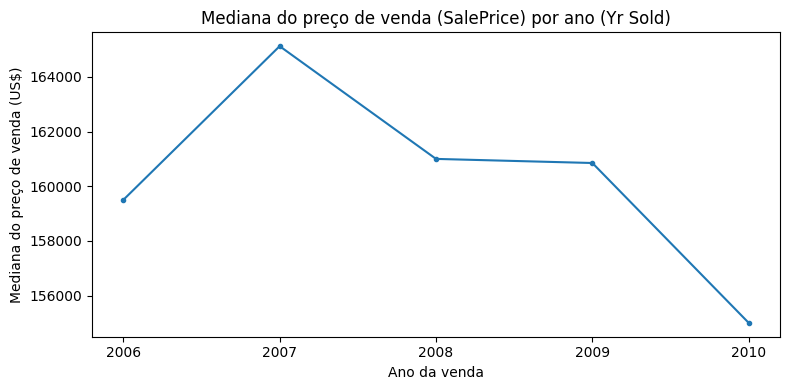

In [1281]:
# Representar os resumos anuais como na linha da aula 06.
plt.figure(figsize=(8, 4))
plt.plot(anual.index, anual["Mediana (US$)"].values, marker='o', markersize=3)
plt.title('Mediana do preço de venda (SalePrice) por ano (Yr Sold)')
plt.xlabel('Ano da venda')
plt.ylabel('Mediana do preço de venda (US$)')
plt.xticks(anual.index)
plt.tight_layout()
plt.show()

**Figura 4 - Mediana anual do preço.** A mediana passa de US$ 159.500 em 2006 para US$ 165.125 em 2007 e chega a US$ 155.000 em 2010. A linha compara vendas de imóveis diferentes.

**Natureza observacional:** As vendas não foram controladas experimentalmente; a composição dos imóveis pode mudar a cada ano.


**Período e local:** A figura abrange somente Ames, Iowa, de 2006 a 2010, com cinco resumos anuais.


**Representatividade:** Os imóveis vendidos em cada ano e a menor quantidade de 2010 limitam comparações com o mercado geral.


**Decisões de preparação:** A agregação usa medianas anuais e preços nominais, sem ajuste pela inflação; a mediana esconde diferenças internas de cada ano.


**Valor discrepante e erro:** Preços extremos foram mantidos; a mediana é menos sensível a eles, mas essa robustez não comprova a validade dos registros.


**Associação e causalidade:** Composição das vendas, inflação e condições de mercado podem explicar diferenças; a linha não é trajetória do mesmo imóvel, tendência causal nem análise formal de série temporal.


## 6.2 Preço e área construída

Cada ponto representa uma venda. Vamos observar se imóveis maiores tendem a ter preços maiores, como os pontos se espalham e quais se afastam dos demais.

In [1282]:
# Calcular a covariância pela definição
def covariancia(x: pd.Series, y: pd.Series) -> float:
    if x.isna().any() or y.isna().any():
        raise ValueError('Selecione os pares completos antes do cálculo.')
    n = len(x)

    #média = sum() / n
    mx = sum(x) / n
    my = sum(y) / n

    soma = 0.0
    for xi, yi in zip(x, y):
        soma += (xi - mx) * (yi - my)
    return soma / (n - 1)

In [1283]:
def pearson(a: pd.Series, b: pd.Series):
  pares = pd.concat([a, b], axis=1).dropna()
  dp_a = pares[0].std()
  dp_b = pares[1].std()


In [1284]:
pares = df[["Gr Liv Area", "SalePrice"]].dropna()


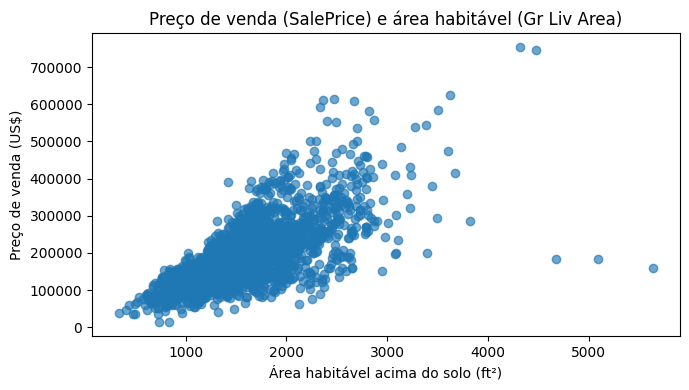

In [1285]:
# Representar os pares de medidas como na aula 06.
plt.figure(figsize=(7, 4))
plt.scatter(df['Gr Liv Area'], df['SalePrice'], alpha=0.65)
plt.title('Preço de venda (SalePrice) e área habitável (Gr Liv Area)')
plt.xlabel('Área habitável acima do solo (ft²)')
plt.ylabel('Preço de venda (US$)')
plt.tight_layout()
plt.show()

In [1286]:
print("Living area", df["Gr Liv Area"].corr(df["SalePrice"], method='pearson'))

Living area 0.7067799209766279


Coeficiente de Pearson (Pós remoção dos extremos)

---

In [1287]:
def turkey(var: pd.Series):
  q1, q3 = var.quantile([0.25,0.75])
  IQR = q3 - q1
  maior = q3 + (IQR*1.5)
  menor = q1 - (IQR*1.5)
  invalid_indexes = list()
  for i in range(0,len(var)):
    if(var[i]>maior or var[i]<menor):
      invalid_indexes.append(i)

  clean: pd.Series = var.drop(index=invalid_indexes)
  return clean


In [1288]:
sale_limpo = turkey(df['SalePrice'])
gr_limpo = turkey(df['Gr Liv Area'])

In [1289]:
print(f"Pearson: {gr_limpo.corr(sale_limpo,method='pearson')}")

Pearson: 0.6660135998543565


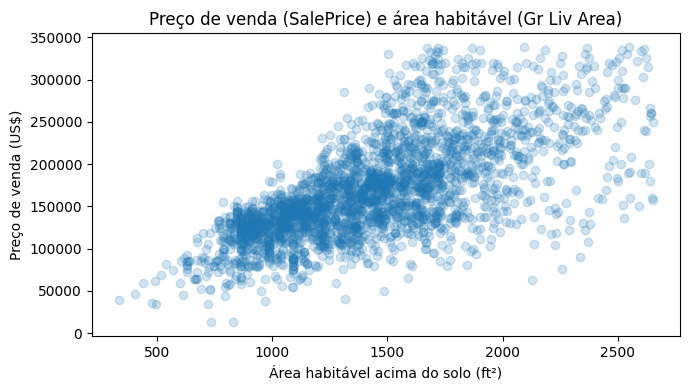

In [1290]:
# Representar os pares de medidas como na aula 06.
agrupado = pd.concat([sale_limpo, gr_limpo], axis=1).dropna()
plt.figure(figsize=(7, 4))
plt.scatter(agrupado['Gr Liv Area'], agrupado['SalePrice'], alpha=0.2)
plt.title('Preço de venda (SalePrice) e área habitável (Gr Liv Area)')
plt.xlabel('Área habitável acima do solo (ft²)')
plt.ylabel('Preço de venda (US$)')
plt.tight_layout()
plt.show()

**Figura 5 - Dispersão entre área e preço.** Os preços tendem a aumentar com a área, mas imóveis de área parecida podem ter preços distintos. A nuvem principal não mostra grupos bem separados; alguns imóveis muito grandes têm preços próximos à mediana.

**Natureza observacional:** A área e o preço foram observados nas vendas; outras características dos imóveis não foram controladas.


**Período e local:** A associação corresponde a Ames, Iowa, entre 2006 e 2010, com preços nominais de anos diferentes.


**Representatividade:** O padrão observado descreve estas vendas e pode ser diferente em outras cidades ou períodos.

**Decisões de preparação:** Usamos os pares completos e preservamos todos os extremos; neste arquivo não faltam preço nem área.


**Valor discrepante e erro:** Os pontos de grande área e preço moderado merecem investigação. Sua posição no gráfico, sozinha, não comprova erro.

**Associação e causalidade:** Área e preço estão associados, mas a figura não isola efeitos de localização, conservação ou qualidade e não demonstra causalidade.


## 6.3 Preço por tipo de imóvel

Vamos comparar a quantidade, a mediana e a dispersão do preço entre os cinco tipos de imóvel. Os grupos têm tamanhos diferentes, e a comparação é apenas descritiva.

In [1291]:
por_tipo = df.groupby("tipo_imovel", observed=True)["SalePrice"]
resumo_tipo = pd.DataFrame({
    "Quantidade": por_tipo.count(),
    "Mediana (US$)": por_tipo.median(),
    "Q1 (US$)": por_tipo.quantile(0.25),
    "Q3 (US$)": por_tipo.quantile(0.75)
}).reindex(ordem)
resumo_tipo["IQR (US$)"] = resumo_tipo["Q3 (US$)"] - resumo_tipo["Q1 (US$)"]
resumo_tipo.index.name = "Tipo de imóvel (Bldg Type)"
resumo_tipo

,Quantidade,Mediana (US$),Q1 (US$),Q3 (US$),IQR (US$)
Tipo de imóvel (Bldg Type),,,,,
Casa independente (1Fam),2425,165000.0,130000.0,220000.0,90000.0
Casa convertida (2fmCon),62,122250.0,106562.5,140000.0,33437.5
Duas unidades (Duplex),109,136905.0,118858.0,153337.0,34479.0
Geminada na ponta (TwnhsE),233,180000.0,145000.0,222000.0,77000.0
Geminada interna (Twnhs),101,130000.0,100500.0,170000.0,69500.0


**Tabela 10 - Preço por tipo de imóvel.** Geminadas na ponta têm a maior mediana (US$ 180.000), e casas convertidas, a menor (US$ 122.250). Casas independentes têm o maior IQR (US$ 90.000). Essas diferenças não isolam efeitos de área, localização ou conservação.

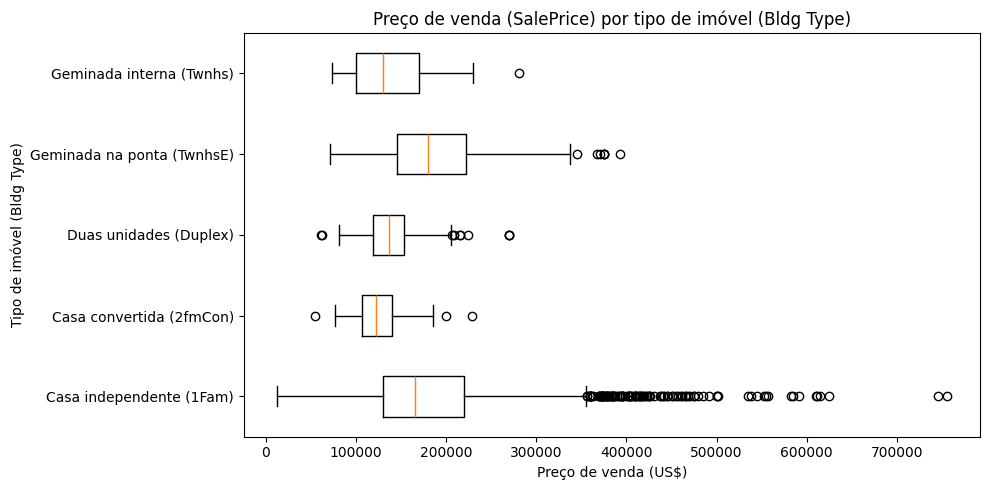

In [1292]:
# Usar o boxplot horizontal da aula 07 para cada tipo.
precos_por_tipo = [
    df.loc[df["tipo_imovel"] == rotulo, "SalePrice"].dropna()
    for rotulo in ordem
]
fig, eixo = plt.subplots(figsize=(10, 5))
eixo.boxplot(precos_por_tipo, vert=False)
eixo.set_yticks(range(1, len(ordem) + 1), ordem)
eixo.set_xlabel("Preço de venda (US$)")
eixo.set_ylabel("Tipo de imóvel (Bldg Type)")
eixo.set_title("Preço de venda (SalePrice) por tipo de imóvel (Bldg Type)")
plt.tight_layout()
plt.show()

**Figura 6 - Boxplots do preço por tipo de imóvel.** As caixas se sobrepõem, apesar das diferenças entre medianas. Casas independentes têm maior dispersão central e os maiores preços extremos. Os pontos além das hastes usam as cercas de cada grupo, que diferem das cercas gerais. O gráfico não demonstra causalidade.

# 7. Conclusão e limitações

Os preços se concentram nos valores mais baixos, com poucos imóveis muito caros. A mediana geral é US$ 160.000. Imóveis maiores tendem a custar mais, mas há exceções. Os tipos de imóvel apresentam diferenças de mediana e dispersão.

A análise descreve vendas em Ames entre 2006 e 2010, com preços nominais. Os grupos têm tamanhos diferentes, e os dados não representam automaticamente outras cidades. Ausências e extremos foram preservados; as comparações mostram associações, sem provar causas.

# 8. Contribuições dos integrantes

Arthur Ramos Souza e Samylla Miguel Barbosa realizaram todas as etapas do trabalho em conjunto.

# 9. Declaração de uso de inteligência artificial

Foi utilizado o Codex (OpenAI) para revisar o notebook, ajustar B para `Bldg Type`, completar a análise de valores discrepantes e os gráficos e revisar os textos. A validação técnica incluiu execução sequencial e conferência dos cálculos e das categorias. A dupla deve revisar o conteúdo e compreender as decisões antes da entrega.

# 10. Fontes

- [Enunciado da AP1 — Ricardo Carubbi](https://github.com/carubbi/MQ/blob/main/trabalhos/ap1.md).
- [AmesHousing.txt — arquivo fornecido pelo professor](https://github.com/carubbi/MQ/blob/main/data/raw/AmesHousing.txt).
- [Dicionário de Ames Housing — Dean De Cock](https://github.com/carubbi/MQ/blob/main/data/raw/DataDocumentation.txt).
- [Aula 06 — gráficos](https://github.com/carubbi/MQ/blob/main/notebooks/resolvidos/u1_a06.ipynb).
- [Aula 07 — medidas e boxplot](https://github.com/carubbi/MQ/blob/main/notebooks/resolvidos/u1_a07.ipynb).
- Notebooks de sala `u1_a01`, `u1_a02` e `u1_a05`.